# IP102 Broad15 Deep CNN V2 - Farm Pest Classification

This notebook trains the team's scratch-built Deep V2 CNN on the Broad15 farm-pest subset from IP102. It uses the same official splits and training protocol as the Broad15 baseline notebook. Validation macro F1 selects the checkpoint; the test split remains untouched during model development.

> **Dataset compatibility notice:** This notebook uses the IP102 **Classification** images and official train/validation/test splits. The repository's main application benchmark uses cropped IP102 **Detection** images and a custom `detection_top15` split. The architecture can be integrated into the application, but this notebook's metrics and checkpoint are not directly comparable with models trained under the main benchmark protocol.

**Model constraint:** only primitive PyTorch layers, random initialization, no pretrained weights, and no imported prebuilt CNN architecture.

## 1. Imports and reproducibility

In [1]:
from pathlib import Path
import copy
import csv
import json
import random
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
XPU_AVAILABLE = hasattr(torch, 'xpu') and torch.xpu.is_available()
if XPU_AVAILABLE:
    torch.xpu.manual_seed_all(SEED)
elif torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

if XPU_AVAILABLE:
    DEVICE = torch.device('xpu')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'PyTorch version: {torch.__version__}')
print(f'Device: {DEVICE}')
if DEVICE.type == 'xpu':
    print(f'GPU: {torch.xpu.get_device_name(0)}')

PyTorch version: 2.13.0+xpu
Device: xpu
GPU: Intel(R) Arc(TM) Graphics


In [2]:
# Verify that this kernel can execute tensor operations on an Intel GPU.
print(f'XPU API present: {hasattr(torch, "xpu")}')
print(f'XPU available: {XPU_AVAILABLE}')

if XPU_AVAILABLE:
    print(f'XPU device count: {torch.xpu.device_count()}')
    print(f'XPU device 0: {torch.xpu.get_device_name(0)}')
    verification_x = torch.randn(1024, 1024, device='xpu')
    verification_y = verification_x @ verification_x
    torch.xpu.synchronize()
    print(f'XPU matrix-multiplication test passed on {verification_y.device}.')
    del verification_x, verification_y
else:
    print('Intel XPU is unavailable; select the Intel XPU notebook kernel and check the PyTorch build and graphics driver.')

XPU API present: True
XPU available: True
XPU device count: 1
XPU device 0: Intel(R) Arc(TM) Graphics
XPU matrix-multiplication test passed on xpu:0.


## 2. Paths, selected classes, and training configuration

The notebook preserves the official IP102 train, validation, and test splits. Original IP102 labels are remapped to contiguous project labels `0-9`.

In [3]:
# This works when Jupyter starts in the repository, notebooks folder, or workspace root.
PROJECT_DIR = Path.cwd().resolve()
if PROJECT_DIR.name == 'notebooks':
    PROJECT_DIR = PROJECT_DIR.parent
elif not (PROJECT_DIR / 'configs' / '_base.yaml').exists():
    repository_candidate = PROJECT_DIR / 'FarmPestManagementAI'
    if repository_candidate.exists():
        PROJECT_DIR = repository_candidate

DATA_ROOT = PROJECT_DIR / 'IP102_v1.1' / 'Classification' / 'ip102_v1.1'
IMAGE_DIR = DATA_ROOT / 'images'
BROAD15_DEFINITION_FILE = PROJECT_DIR / 'data_manifests' / 'broad15_classes.json'
EXPERIMENT_NAME = 'broad15_deep_cnn_v2'
RUN_DIR = PROJECT_DIR / 'runs' / 'broad15' / EXPERIMENT_NAME
RUN_DIR.mkdir(parents=True, exist_ok=True)

assert (PROJECT_DIR / 'configs' / 'broad15_deep_v2.yaml').exists(), (
    f'FarmPestManagementAI repository not found from: {Path.cwd()}'
)
assert DATA_ROOT.exists(), f'Dataset folder not found: {DATA_ROOT}'
assert IMAGE_DIR.exists(), f'Image folder not found: {IMAGE_DIR}'
assert BROAD15_DEFINITION_FILE.exists(), f'Broad15 definition not found: {BROAD15_DEFINITION_FILE}'

broad15_definition = json.loads(BROAD15_DEFINITION_FILE.read_text(encoding='utf-8'))
assert broad15_definition['num_classes'] == 15
SELECTED_ORIGINAL_IDS = [item['original_label'] for item in broad15_definition['classes']]
CLASS_NAMES = [item['class_name'] for item in broad15_definition['classes']]
EXPECTED_TOTALS = broad15_definition['expected_totals']
ORIGINAL_TO_PROJECT = {
    original_id: project_id
    for project_id, original_id in enumerate(SELECTED_ORIGINAL_IDS)
}

NUM_CLASSES = len(CLASS_NAMES)

IMAGE_SIZE = 160
BATCH_SIZE = 32
MAX_EPOCHS = 50
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 10
NUM_WORKERS = 0  # Safest setting for Jupyter on Windows.

# Change this to True for a quick 3-epoch pipeline check.
QUICK_RUN = False
if QUICK_RUN:
    MAX_EPOCHS = 3

print(f'Project directory: {PROJECT_DIR}')
print(f'Dataset directory: {DATA_ROOT}')
print(f'V2 output directory: {RUN_DIR}')
assert RUN_DIR.name == 'broad15_deep_cnn_v2'
print(f'Classes ({NUM_CLASSES}):')
for project_id, (original_id, name) in enumerate(zip(SELECTED_ORIGINAL_IDS, CLASS_NAMES)):
    print(f'  project {project_id} <- IP102 {original_id}: {name}')

Project directory: C:\Users\justi\Programming Projs\FPT-MLCV\FarmPestManagementAI
Dataset directory: C:\Users\justi\Programming Projs\FPT-MLCV\FarmPestManagementAI\IP102_v1.1\Classification\ip102_v1.1
V2 output directory: C:\Users\justi\Programming Projs\FPT-MLCV\FarmPestManagementAI\runs\broad15\broad15_deep_cnn_v2
Classes (15):
  project 0 <- IP102 14: grub
  project 1 <- IP102 15: mole_cricket
  project 2 <- IP102 16: wireworm
  project 3 <- IP102 18: black_cutworm
  project 4 <- IP102 22: corn_borer
  project 5 <- IP102 23: army_worm
  project 6 <- IP102 24: aphids
  project 7 <- IP102 37: flea_beetle
  project 8 <- IP102 45: flax_budworm
  project 9 <- IP102 47: tarnished_plant_bug
  project 10 <- IP102 51: blister_beetle
  project 11 <- IP102 69: cicadella_viridis
  project 12 <- IP102 70: miridae
  project 13 <- IP102 86: prodenia_litura
  project 14 <- IP102 101: cicadellidae


## 3. Dataset class and image transformations

V2 applies mild random augmentation only to the training set: a tighter crop, horizontal flips, rotation, and light colour jitter. Gaussian blur and random erasing are intentionally removed. Validation and test images use deterministic preprocessing.

In [4]:
NORMALIZE_MEAN = (0.5, 0.5, 0.5)
NORMALIZE_STD = (0.5, 0.5, 0.5)

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.90, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
])


class IP102Broad15Dataset(Dataset):
    """Filtered IP102 classification split with contiguous project labels."""

    def __init__(self, split, transform=None):
        if split not in {'train', 'val', 'test'}:
            raise ValueError("split must be 'train', 'val', or 'test'")

        self.split = split
        self.transform = transform
        self.records = []

        split_file = DATA_ROOT / f'{split}.txt'
        for line in split_file.read_text(encoding='utf-8').splitlines():
            filename, original_label_text = line.split()
            original_label = int(original_label_text)
            if original_label in ORIGINAL_TO_PROJECT:
                self.records.append((filename, ORIGINAL_TO_PROJECT[original_label]))

        self.labels = [label for _, label in self.records]

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        filename, label = self.records[index]
        image_path = IMAGE_DIR / filename
        with Image.open(image_path) as image:
            image = image.convert('RGB')
            if self.transform is not None:
                image = self.transform(image)
        return image, label, filename

## 4. Data loaders and integrity checks

In [5]:
train_dataset = IP102Broad15Dataset('train', transform=train_transform)
val_dataset = IP102Broad15Dataset('val', transform=eval_transform)
test_dataset = IP102Broad15Dataset('test', transform=eval_transform)

assert len(train_dataset) == EXPECTED_TOTALS['train']
assert len(val_dataset) == EXPECTED_TOTALS['validation']
assert len(test_dataset) == EXPECTED_TOTALS['test']
assert set(train_dataset.labels) == set(range(NUM_CLASSES))

loader_options = {
    'batch_size': BATCH_SIZE,
    'num_workers': NUM_WORKERS,
    'pin_memory': DEVICE.type != 'cpu',
}

train_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    generator=train_generator,
    **loader_options,
)
val_loader = DataLoader(val_dataset, shuffle=False, **loader_options)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_options)

sample_images, sample_labels, sample_filenames = next(iter(train_loader))
print(f'Train images:      {len(train_dataset):,}')
print(f'Validation images: {len(val_dataset):,}')
print(f'Test images:       {len(test_dataset):,}')
print(f'Batch image shape: {tuple(sample_images.shape)}')
print(f'Batch label range: {sample_labels.min().item()}-{sample_labels.max().item()}')

Train images:      17,448
Validation images: 2,906
Test images:       8,735
Batch image shape: (32, 3, 160, 160)
Batch label range: 1-14


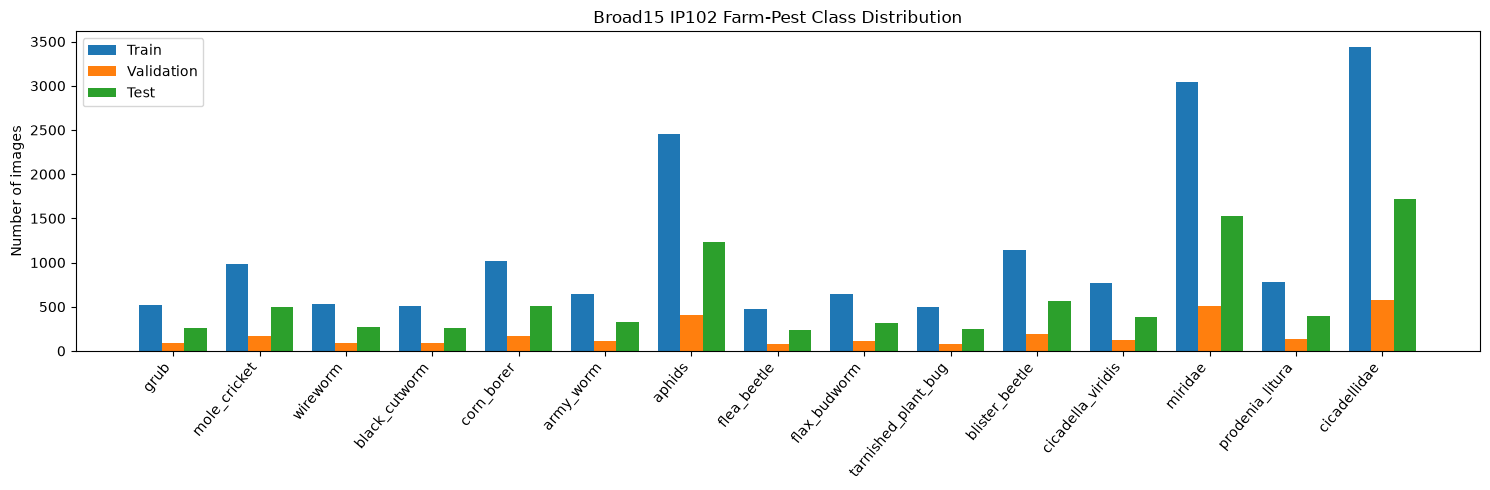

In [8]:
# Class-distribution chart for the official IP102 splits.
split_datasets = [train_dataset, val_dataset, test_dataset]
split_names = ['Train', 'Validation', 'Test']
split_counts = [
    np.bincount(dataset.labels, minlength=NUM_CLASSES)
    for dataset in split_datasets
]

x = np.arange(NUM_CLASSES)
width = 0.26
plt.figure(figsize=(15, 5))
for offset, counts, split_name in zip([-width, 0, width], split_counts, split_names):
    plt.bar(x + offset, counts, width=width, label=split_name)
plt.xticks(x, CLASS_NAMES, rotation=50, ha='right')
plt.ylabel('Number of images')
plt.title('Broad15 IP102 Farm-Pest Class Distribution')
plt.legend()
plt.tight_layout()
plt.show()

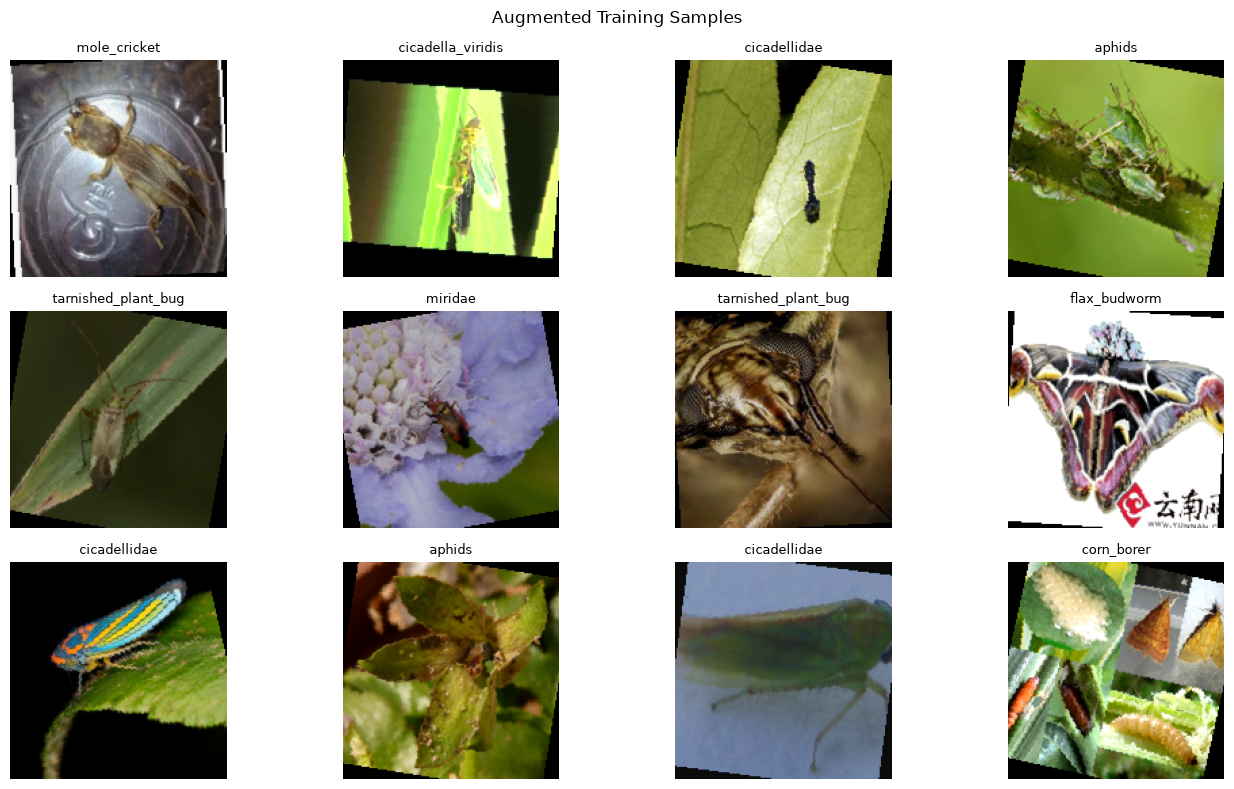

In [6]:
# Preview augmented training images.
def denormalize(image_tensor):
    mean = torch.tensor(NORMALIZE_MEAN).view(3, 1, 1)
    std = torch.tensor(NORMALIZE_STD).view(3, 1, 1)
    return (image_tensor.cpu() * std + mean).clamp(0, 1)


plt.figure(figsize=(14, 8))
for index in range(min(12, len(sample_images))):
    plt.subplot(3, 4, index + 1)
    image = denormalize(sample_images[index]).permute(1, 2, 0).numpy()
    plt.imshow(image)
    plt.title(CLASS_NAMES[sample_labels[index].item()], fontsize=9)
    plt.axis('off')
plt.suptitle('Augmented Training Samples')
plt.tight_layout()
plt.show()

## 5. Scratch-built deep sequential CNN

The architecture contains four feature stages with two convolutions per stage, light spatial dropout in only the final two stages, global average pooling, and a dense classifier. V2 uses stage dropouts `(0.00, 0.00, 0.05, 0.10)` and classifier dropout `0.20`. The imported module was written by the team from primitive layers and performs explicit Kaiming random initialization.

In [7]:
# Make the repository package importable regardless of notebook launch folder.
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from src.models import build_model

model = build_model(
    'justin_deep_v2',
    num_classes=NUM_CLASSES,
    classifier_dropout=0.20,
    stage_dropouts=(0.00, 0.00, 0.05, 0.10),
).to(DEVICE)
trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

with torch.inference_mode():
    shape_check = model(torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE))

print(model)
print(f'Output shape check: {tuple(shape_check.shape)}')
print(f'Trainable parameters: {trainable_parameters:,}')
assert shape_check.shape == (2, NUM_CLASSES)
# The original 10-class model has 1,241,578 parameters. Each extra output
# adds 256 classifier weights plus one bias value.
expected_parameters = 1_241_578 + (NUM_CLASSES - 10) * (256 + 1)
assert trainable_parameters == expected_parameters
print(f'Expected Broad15 parameter count confirmed: {expected_parameters:,}')

JustinDeepCNN(
  (features): Sequential(
    (0): ConvStage(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): ConvStage(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, 

## 6. Loss, optimizer, class weights, and scheduler

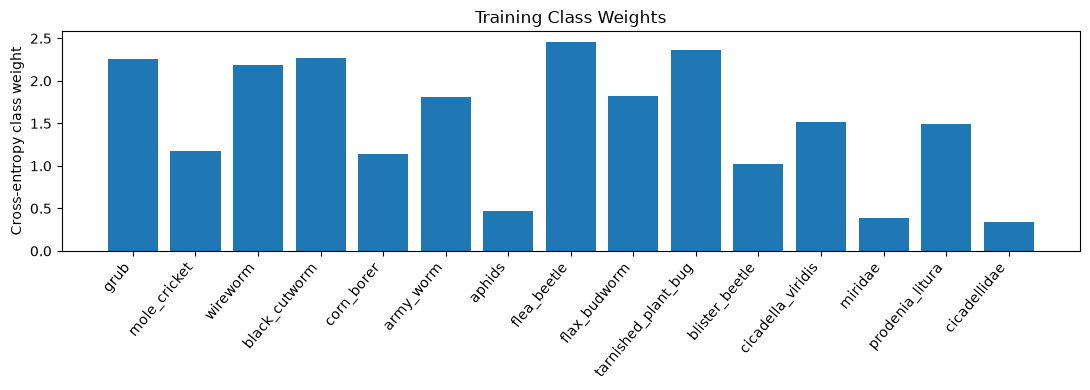

In [8]:
train_class_counts = np.bincount(train_dataset.labels, minlength=NUM_CLASSES)
class_weights = len(train_dataset) / (NUM_CLASSES * train_class_counts)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3,
)

plt.figure(figsize=(11, 4))
plt.bar(CLASS_NAMES, class_weights)
plt.xticks(rotation=50, ha='right')
plt.ylabel('Cross-entropy class weight')
plt.title('Training Class Weights')
plt.tight_layout()
plt.show()

## 7. Training and evaluation helpers

In [9]:
def confusion_matrix_update(confusion, labels, predictions, num_classes):
    indices = labels * num_classes + predictions
    counts = torch.bincount(indices, minlength=num_classes * num_classes)
    confusion += counts.reshape(num_classes, num_classes).cpu()


def metrics_from_confusion(confusion):
    confusion = confusion.to(torch.float64)
    true_positive = confusion.diag()
    predicted_count = confusion.sum(dim=0)
    actual_count = confusion.sum(dim=1)

    precision = true_positive / predicted_count.clamp_min(1)
    recall = true_positive / actual_count.clamp_min(1)
    f1 = 2 * precision * recall / (precision + recall).clamp_min(1e-12)
    accuracy = true_positive.sum() / confusion.sum().clamp_min(1)

    return {
        'accuracy': accuracy.item(),
        'macro_precision': precision.mean().item(),
        'macro_recall': recall.mean().item(),
        'macro_f1': f1.mean().item(),
        'per_class_precision': precision.numpy(),
        'per_class_recall': recall.numpy(),
        'per_class_f1': f1.numpy(),
    }


def run_epoch(model, loader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train(is_training)

    total_loss = 0.0
    total_examples = 0
    confusion = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.int64)

    for images, labels, _ in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            logits = model(images)
            loss = criterion(logits, labels)
            if is_training:
                loss.backward()
                optimizer.step()

        predictions = logits.argmax(dim=1)
        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_examples += batch_size
        confusion_matrix_update(confusion, labels, predictions, NUM_CLASSES)

    metrics = metrics_from_confusion(confusion)
    metrics['loss'] = total_loss / total_examples
    metrics['confusion_matrix'] = confusion
    return metrics

## 8. Train the model and print every epoch

The checkpoint with the best validation macro F1 is saved. Training stops early if macro F1 does not improve for the configured patience.

In [10]:
best_model_path = RUN_DIR / "best_model.pt"

checkpoint = torch.load(
    best_model_path,
    map_location=DEVICE,
    weights_only=True,
)
model.load_state_dict(checkpoint["model_state_dict"])

start_epoch = checkpoint["epoch"] + 1
best_epoch = checkpoint["epoch"]
best_val_f1 = checkpoint["val_macro_f1"]
epochs_without_improvement = 0

print(
    f"Resuming from best epoch {best_epoch}, "
    f"validation macro F1 {best_val_f1:.4f}"
)

Resuming from best epoch 25, validation macro F1 0.4859


In [11]:
history = {
    'train_loss': [],
    'val_loss': [],
    'train_accuracy': [],
    'val_accuracy': [],
    'train_macro_f1': [],
    'val_macro_f1': [],
    'learning_rate': [],
}

assert EXPERIMENT_NAME == 'broad15_deep_cnn_v2'
assert RUN_DIR.name == EXPERIMENT_NAME
print(f'Starting V2 training; all outputs will be saved to: {RUN_DIR}')

    # best_val_f1 = -1.0
    # best_epoch = 0
    # epochs_without_improvement = 0
best_model_path = RUN_DIR / 'best_model.pt'
training_start = time.perf_counter()

for epoch in range(start_epoch, MAX_EPOCHS + 1):
    epoch_start = time.perf_counter()
    train_metrics = run_epoch(model, train_loader, criterion, optimizer=optimizer)
    val_metrics = run_epoch(model, val_loader, criterion)

    current_lr = optimizer.param_groups[0]['lr']
    history['train_loss'].append(train_metrics['loss'])
    history['val_loss'].append(val_metrics['loss'])
    history['train_accuracy'].append(train_metrics['accuracy'])
    history['val_accuracy'].append(val_metrics['accuracy'])
    history['train_macro_f1'].append(train_metrics['macro_f1'])
    history['val_macro_f1'].append(val_metrics['macro_f1'])
    history['learning_rate'].append(current_lr)

    scheduler.step(val_metrics['macro_f1'])

    improved = val_metrics['macro_f1'] > best_val_f1
    if improved:
        best_val_f1 = val_metrics['macro_f1']
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save(
            {
                'model_state_dict': model.state_dict(),
                'epoch': epoch,
                'val_macro_f1': best_val_f1,
                'class_names': CLASS_NAMES,
                'selected_original_ids': SELECTED_ORIGINAL_IDS,
                'experiment_name': EXPERIMENT_NAME,
                'classifier_dropout': 0.20,
                'stage_dropouts': (0.00, 0.00, 0.05, 0.10),
                'learning_rate': LEARNING_RATE,
            },
            best_model_path,
        )
    else:
        epochs_without_improvement += 1

    elapsed = time.perf_counter() - epoch_start
    marker = ' * best' if improved else ''
    print(
        f'Epoch {epoch:02d}/{MAX_EPOCHS} | '
        f'Train loss {train_metrics["loss"]:.4f}, '
        f'acc {train_metrics["accuracy"]:.3f}, F1 {train_metrics["macro_f1"]:.3f} | '
        f'Val loss {val_metrics["loss"]:.4f}, '
        f'acc {val_metrics["accuracy"]:.3f}, F1 {val_metrics["macro_f1"]:.3f} | '
        f'LR {current_lr:.2e} | {elapsed:.1f}s{marker}'
    )

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f'Early stopping after {epoch} epochs.')
        break

training_minutes = (time.perf_counter() - training_start) / 60
print(f'Finished training in {training_minutes:.1f} minutes.')
print(f'Best epoch: {best_epoch}; validation macro F1: {best_val_f1:.4f}')
print(f'Checkpoint: {best_model_path}')

# Save epoch history in a portable CSV file.
history_path = RUN_DIR / 'training_history.csv'
with history_path.open('w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(['epoch', *history.keys()])
    for index in range(len(history['train_loss'])):
        writer.writerow([index + 1, *[history[key][index] for key in history]])
print(f'History: {history_path}')

Starting V2 training; all outputs will be saved to: C:\Users\justi\Programming Projs\FPT-MLCV\FarmPestManagementAI\runs\broad15\broad15_deep_cnn_v2
Epoch 26/50 | Train loss 1.4123, acc 0.506, F1 0.484 | Val loss 1.5761, acc 0.489, F1 0.449 | LR 5.00e-04 | 323.2s
Epoch 27/50 | Train loss 1.3796, acc 0.511, F1 0.489 | Val loss 1.4313, acc 0.522, F1 0.497 | LR 5.00e-04 | 365.2s * best
Epoch 28/50 | Train loss 1.3588, acc 0.518, F1 0.497 | Val loss 1.4927, acc 0.486, F1 0.475 | LR 5.00e-04 | 324.7s
Epoch 29/50 | Train loss 1.3536, acc 0.530, F1 0.510 | Val loss 1.3957, acc 0.539, F1 0.500 | LR 5.00e-04 | 318.4s * best
Epoch 30/50 | Train loss 1.3218, acc 0.537, F1 0.515 | Val loss 1.5353, acc 0.517, F1 0.486 | LR 5.00e-04 | 332.1s
Epoch 31/50 | Train loss 1.2923, acc 0.537, F1 0.516 | Val loss 1.3943, acc 0.520, F1 0.505 | LR 5.00e-04 | 327.8s * best
Epoch 32/50 | Train loss 1.2705, acc 0.541, F1 0.521 | Val loss 1.4339, acc 0.530, F1 0.505 | LR 5.00e-04 | 328.8s * best
Epoch 33/50 | Train

## 9. Plot loss, accuracy, macro F1, and learning rate

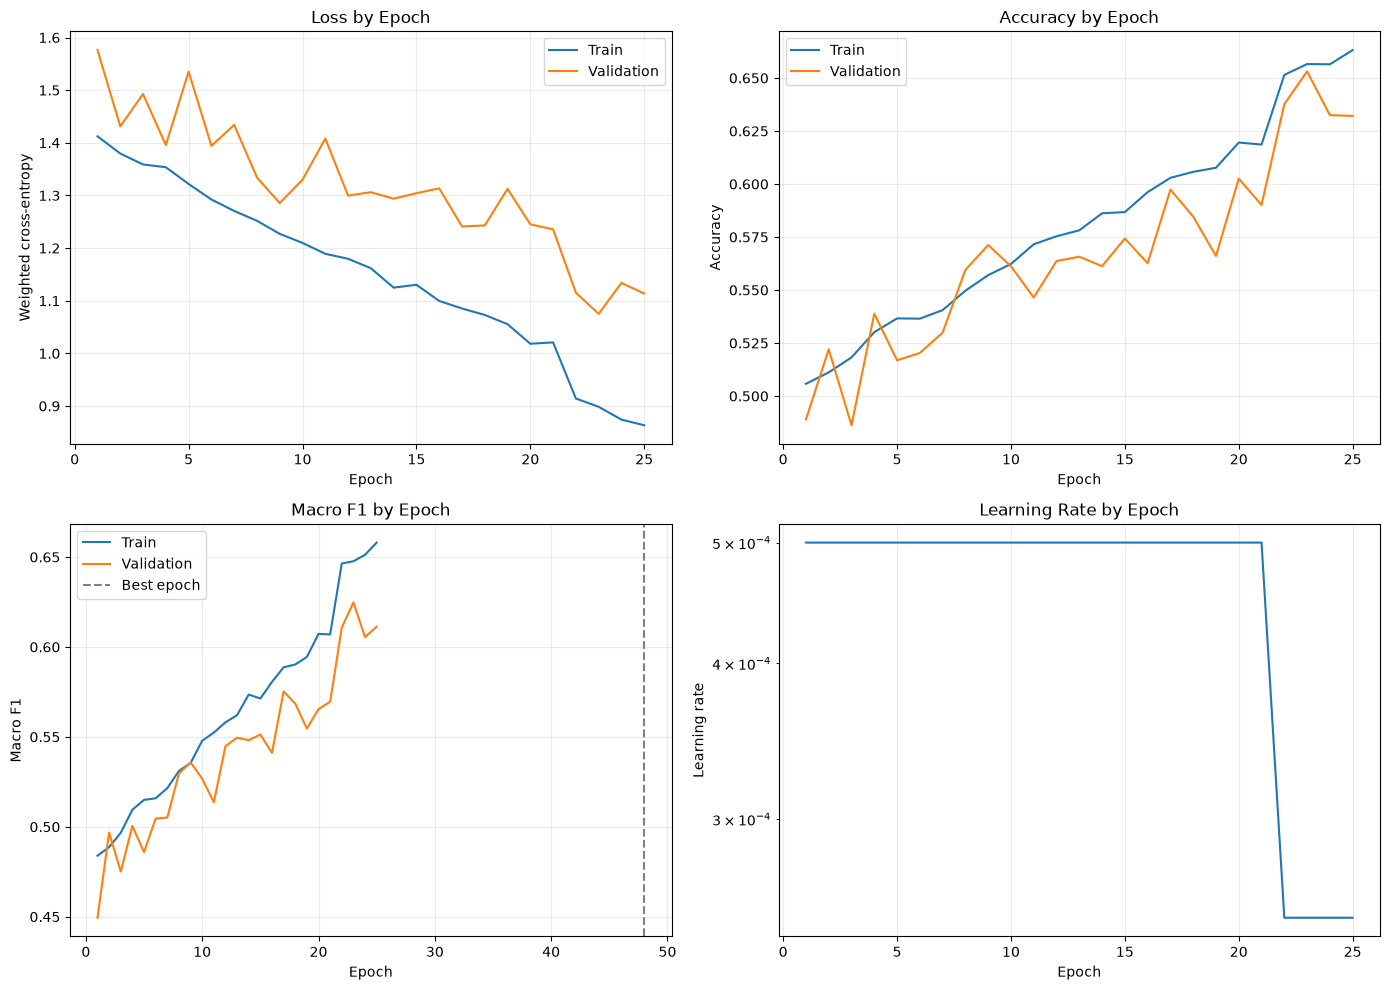

Saved chart: C:\Users\justi\Programming Projs\FPT-MLCV\FarmPestManagementAI\runs\broad15\broad15_deep_cnn_v2\training_curves.png


In [12]:
epochs = np.arange(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(epochs, history['train_loss'], label='Train')
axes[0, 0].plot(epochs, history['val_loss'], label='Validation')
axes[0, 0].set_title('Loss by Epoch')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Weighted cross-entropy')
axes[0, 0].legend()

axes[0, 1].plot(epochs, history['train_accuracy'], label='Train')
axes[0, 1].plot(epochs, history['val_accuracy'], label='Validation')
axes[0, 1].set_title('Accuracy by Epoch')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()

axes[1, 0].plot(epochs, history['train_macro_f1'], label='Train')
axes[1, 0].plot(epochs, history['val_macro_f1'], label='Validation')
axes[1, 0].axvline(best_epoch, color='gray', linestyle='--', label='Best epoch')
axes[1, 0].set_title('Macro F1 by Epoch')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Macro F1')
axes[1, 0].legend()

axes[1, 1].plot(epochs, history['learning_rate'])
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Learning Rate by Epoch')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Learning rate')

for axis in axes.flat:
    axis.grid(alpha=0.25)

plt.tight_layout()
curve_path = RUN_DIR / 'training_curves.png'
plt.savefig(curve_path, dpi=160, bbox_inches='tight')
plt.show()
print(f'Saved chart: {curve_path}')

## 10. Evaluate the best checkpoint on validation data

The test split is deliberately not evaluated during model tuning. Use it once, after the team selects its final configuration.

In [13]:
checkpoint = torch.load(best_model_path, map_location=DEVICE, weights_only=True)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

validation_metrics = run_epoch(model, val_loader, criterion)
print(f'Validation loss:            {validation_metrics["loss"]:.4f}')
print(f'Validation accuracy:        {validation_metrics["accuracy"]:.4f}')
print(f'Validation macro precision: {validation_metrics["macro_precision"]:.4f}')
print(f'Validation macro recall:    {validation_metrics["macro_recall"]:.4f}')
print(f'Validation macro F1:        {validation_metrics["macro_f1"]:.4f}')

print('\nPer-class results:')
for index, name in enumerate(CLASS_NAMES):
    print(
        f'{index:2d} {name:30s} | '
        f'P {validation_metrics["per_class_precision"][index]:.3f} | '
        f'R {validation_metrics["per_class_recall"][index]:.3f} | '
        f'F1 {validation_metrics["per_class_f1"][index]:.3f}'
    )

Validation loss:            1.0751
Validation accuracy:        0.6531
Validation macro precision: 0.6126
Validation macro recall:    0.6583
Validation macro F1:        0.6248

Per-class results:
 0 grub                           | P 0.802 | R 0.756 | F1 0.778
 1 mole_cricket                   | P 0.826 | R 0.836 | F1 0.831
 2 wireworm                       | P 0.628 | R 0.670 | F1 0.648
 3 black_cutworm                  | P 0.612 | R 0.741 | F1 0.670
 4 corn_borer                     | P 0.622 | R 0.676 | F1 0.648
 5 army_worm                      | P 0.495 | R 0.421 | F1 0.455
 6 aphids                         | P 0.695 | R 0.636 | F1 0.664
 7 flea_beetle                    | P 0.541 | R 0.835 | F1 0.657
 8 flax_budworm                   | P 0.417 | R 0.449 | F1 0.432
 9 tarnished_plant_bug            | P 0.269 | R 0.549 | F1 0.361
10 blister_beetle                 | P 0.581 | R 0.799 | F1 0.673
11 cicadella_viridis              | P 0.508 | R 0.758 | F1 0.608
12 miridae               

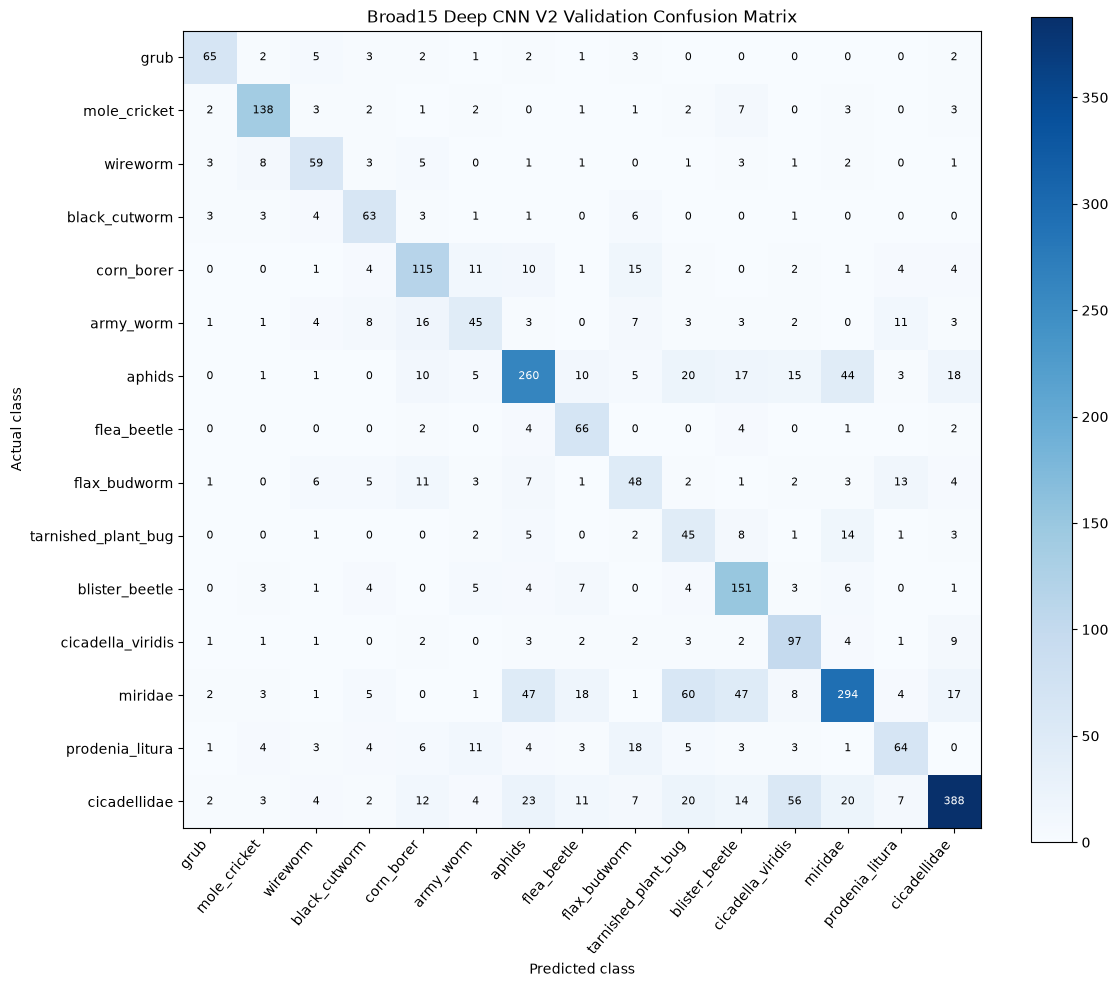

Saved chart: C:\Users\justi\Programming Projs\FPT-MLCV\FarmPestManagementAI\runs\broad15\broad15_deep_cnn_v2\confusion_matrix.png


In [14]:
# Confusion matrix: rows are actual classes and columns are predictions.
confusion = validation_metrics['confusion_matrix'].numpy()
fig, axis = plt.subplots(figsize=(12, 10))
image = axis.imshow(confusion, interpolation='nearest', cmap='Blues')
fig.colorbar(image, ax=axis)
axis.set(
    xticks=np.arange(NUM_CLASSES),
    yticks=np.arange(NUM_CLASSES),
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    xlabel='Predicted class',
    ylabel='Actual class',
    title='Broad15 Deep CNN V2 Validation Confusion Matrix',
)
plt.setp(axis.get_xticklabels(), rotation=50, ha='right')

threshold = confusion.max() / 2
for row in range(NUM_CLASSES):
    for column in range(NUM_CLASSES):
        axis.text(
            column,
            row,
            int(confusion[row, column]),
            ha='center',
            va='center',
            color='white' if confusion[row, column] > threshold else 'black',
            fontsize=8,
        )

plt.tight_layout()
confusion_path = RUN_DIR / 'confusion_matrix.png'
plt.savefig(confusion_path, dpi=160, bbox_inches='tight')
plt.show()
print(f'Saved chart: {confusion_path}')

## 11. Inspect sample validation predictions

Correct predictions are shown in green and errors in red. Each title includes the model confidence.

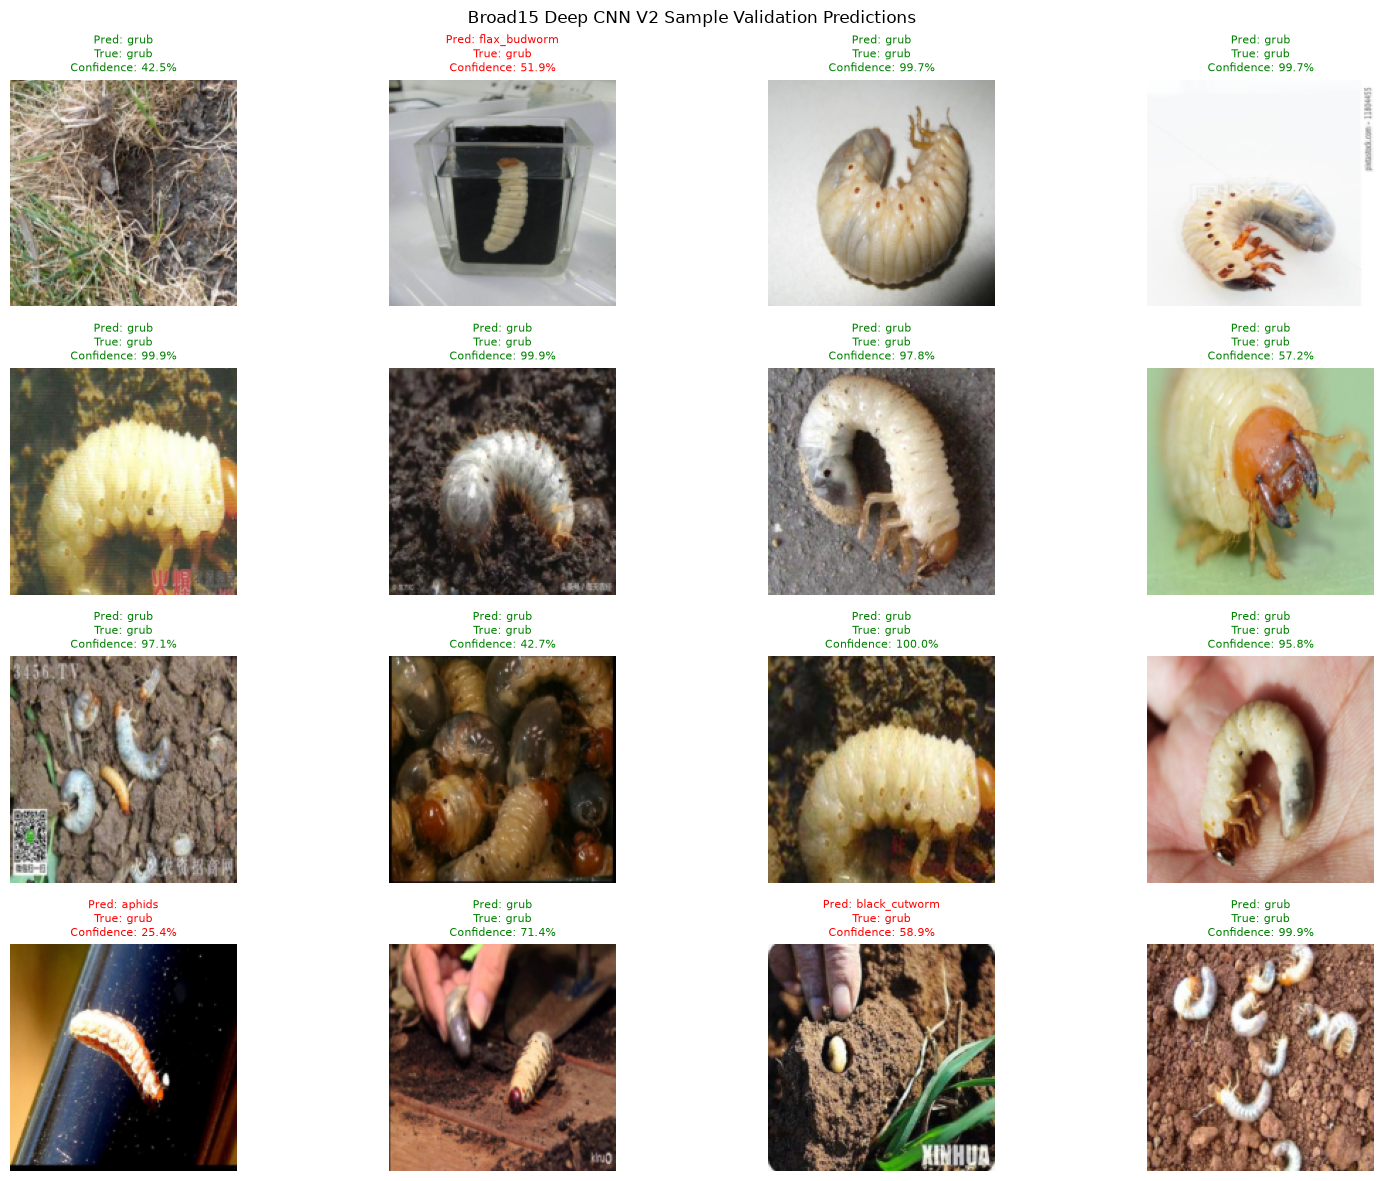

In [15]:
validation_images, validation_labels, validation_filenames = next(iter(val_loader))
with torch.inference_mode():
    probabilities = torch.softmax(model(validation_images.to(DEVICE)), dim=1).cpu()
predictions = probabilities.argmax(dim=1)
confidences = probabilities.max(dim=1).values

plt.figure(figsize=(16, 12))
for index in range(min(16, len(validation_images))):
    actual = validation_labels[index].item()
    predicted = predictions[index].item()
    correct = actual == predicted

    plt.subplot(4, 4, index + 1)
    image = denormalize(validation_images[index]).permute(1, 2, 0).numpy()
    plt.imshow(image)
    plt.title(
        f'Pred: {CLASS_NAMES[predicted]}\n'
        f'True: {CLASS_NAMES[actual]}\n'
        f'Confidence: {confidences[index]:.1%}',
        color='green' if correct else 'red',
        fontsize=8,
    )
    plt.axis('off')
plt.suptitle('Broad15 Deep CNN V2 Sample Validation Predictions')
plt.tight_layout()
plt.show()

## Next experiments

Compare this run with the Broad15 baseline using best validation macro F1, parameter count, training time, and the train-validation gap. Report the untouched test split only after the team selects and freezes its final Broad15 configuration.